<a href="https://colab.research.google.com/github/rddelarosa/DSC1105/blob/main/LAB_FA_3_DSC1105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
library(tidyverse)
data(mpg)

**Part 1: Exploratory Data Analysis (6 points)**





1. (2 pts) Using the mpg dataset, identify:
- Response variable: hwy (highway miles per gallon)
- Explanatory variable: displ (engine displacement in liters)

2. (4 pts) Create the following visualizations using the mpg dataset:
- A scatterplot of hwy vs displ
- One additional plot (histogram or boxplot) for either hwy or displ

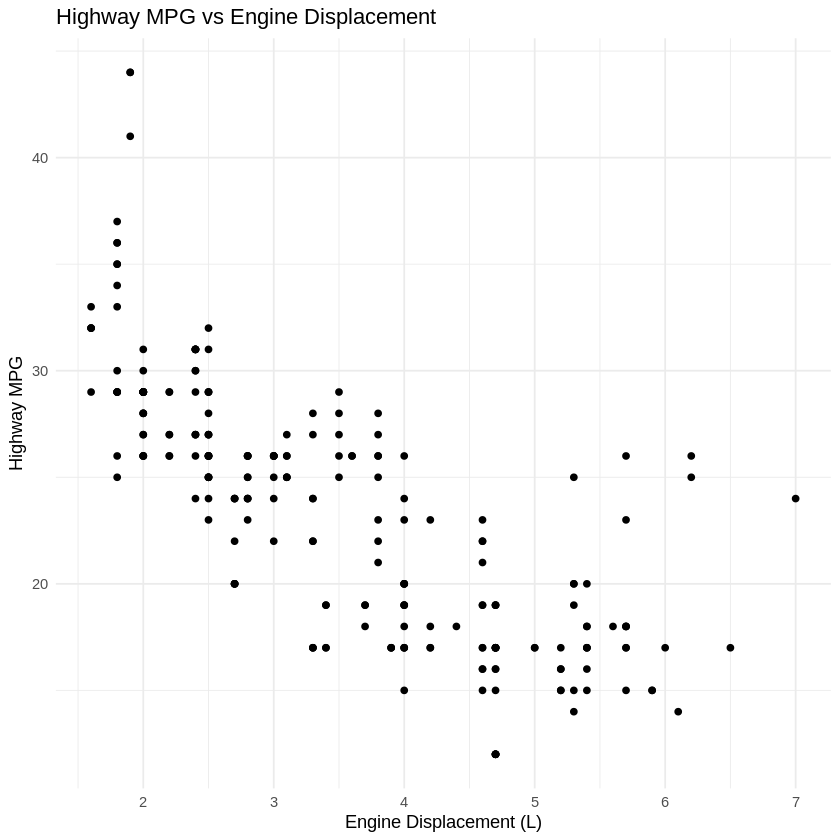

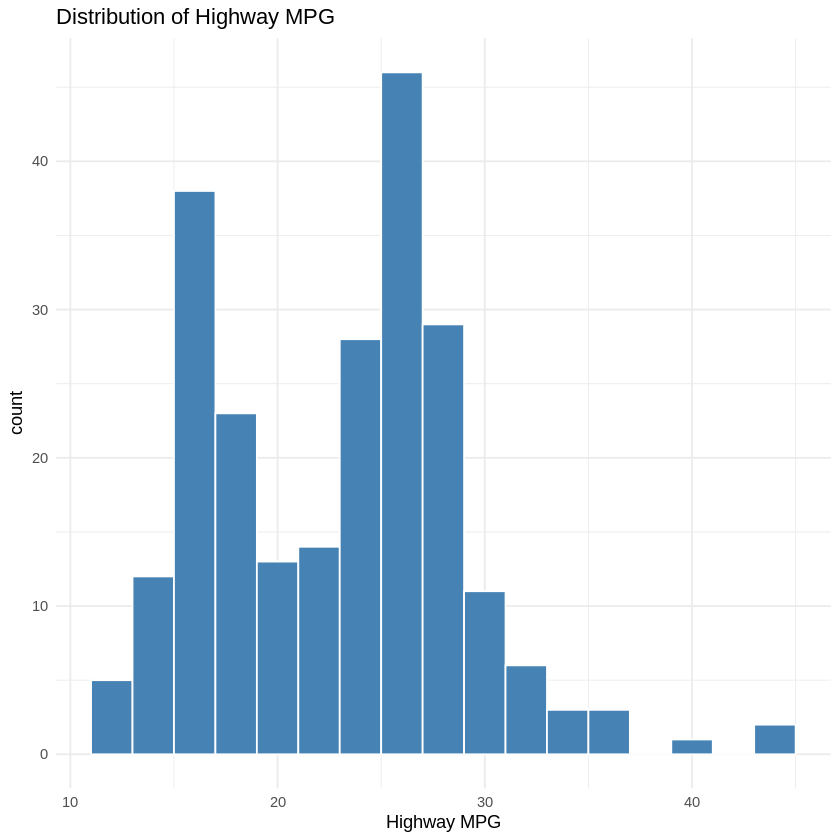

In [14]:
# Scatterplot
ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point() +
  labs(title = "Highway MPG vs Engine Displacement",
       x = "Engine Displacement (L)",
       y = "Highway MPG") +
  theme_minimal()

# Additional Plot: Histogram for hwy
ggplot(mpg, aes(x = hwy)) +
  geom_histogram(binwidth = 2, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Highway MPG", x = "Highway MPG") +
  theme_minimal()

**Part 2: Building a Simple Linear Model (8 points)**



1.(3 pts) Fit a simple linear regression model using the mpg dataset with:
- hwy as the response variable
- displ as the explanatory variable

In [18]:
# Fit the model
mpg_model <- lm(hwy ~ displ, data = mpg)

2. (5 pts) Write the fitted model equation and interpret:
- The slope in terms of engine displacement and highway MPG
- The intercept in context of the data

In [21]:
# Get the coefficients
summary(mpg_model)



Call:
lm(formula = hwy ~ displ, data = mpg)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.1039 -2.1646 -0.2242  2.0589 15.0105 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  35.6977     0.7204   49.55   <2e-16 ***
displ        -3.5306     0.1945  -18.15   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.836 on 232 degrees of freedom
Multiple R-squared:  0.5868,	Adjusted R-squared:  0.585 
F-statistic: 329.5 on 1 and 232 DF,  p-value: < 2.2e-16


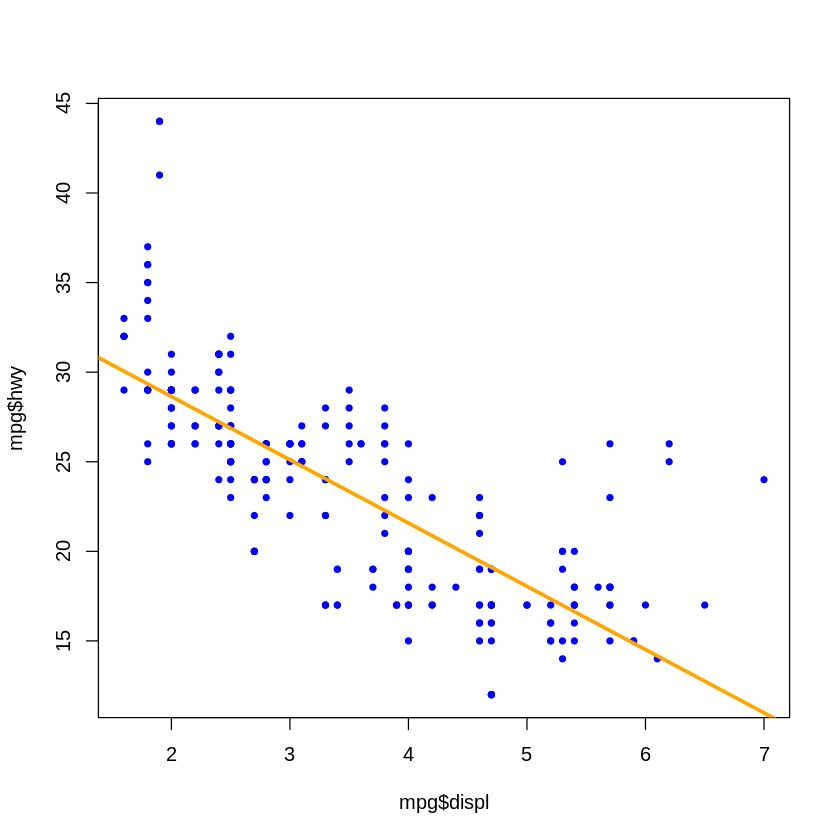

In [45]:
plot (x=mpg$displ, y=mpg$hwy, pch= 20, col="blue")
abline(mpg_model, col = "orange", lwd =3)


**Part 3: Model Assumptions and Diagnostics (8 points)**
1. (5 pts) Using your fitted mpg linear model, assess the following assumptions using diagnostic plots:
- Linearity
- Normality of residuals
- Constant variance (homoscedasticity)

2. (3 pts) Briefly explain whether each assumption appears to be satisfied for the mpg model.



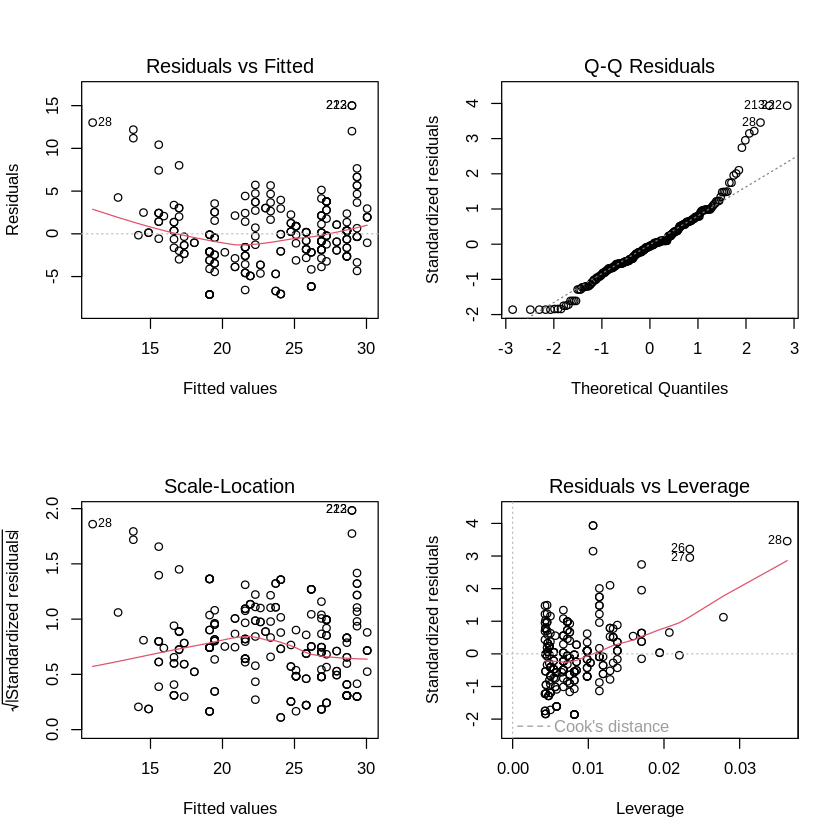

In [8]:
# Diagnostic Plots
par(mfrow = c(2, 2)) # Arrange plots in a 2x2 grid
plot(mpg_model)

**Linearity:** Check the "Residuals vs Fitted" plot. We need red horizontal line and since the red line is curved the relationship is non-linear.

**Normality:** Check the "Normal Q-Q" plot. Since the points follow the dashed line in the middle and curl away on both ends, this suggests the residuals are not perfectly normal and have "heavy tails". Meaning there are more extreme outliers than a normal distribution would expect.

**Homoscedasticity:** Check the "Scale-Location" plot. The red line has a slight upward slant, and the spread of points appears to change as fitted values increase. This suggests heteroscedasticity, meaning the model's accuracy varies depending on the car's engine size.

**Part 4: Transformation or Model Critique (5 points)**
1. (3 pts) If any assumptions are violated in the mpg model, apply an appropriate transformation (e.g., log transformation of displ or hwy) OR justify why no transformation is necessary.

2. (2 pts) Refit the model if transformed and briefly compare it with the original mpg model, or discuss the limitations of the simple linear model for this dataset.




Call:
lm(formula = log(hwy) ~ displ, data = mpg)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.44570 -0.09390  0.00302  0.09476  0.60492 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.661092   0.031201  117.34   <2e-16 ***
displ       -0.155422   0.008425  -18.45   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1661 on 232 degrees of freedom
Multiple R-squared:  0.5946,	Adjusted R-squared:  0.5929 
F-statistic: 340.3 on 1 and 232 DF,  p-value: < 2.2e-16


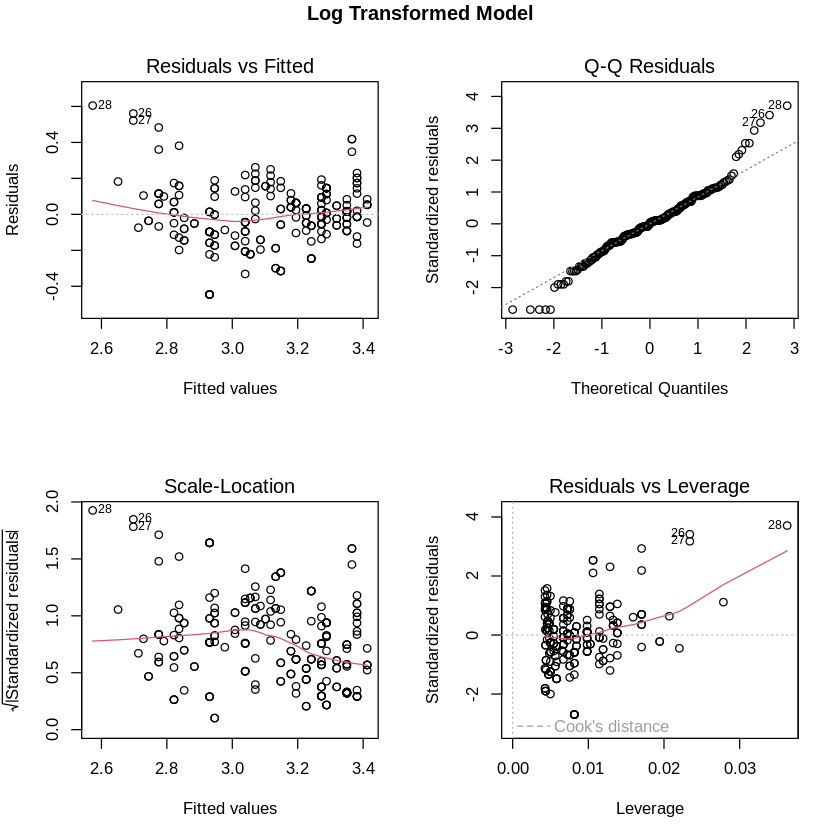

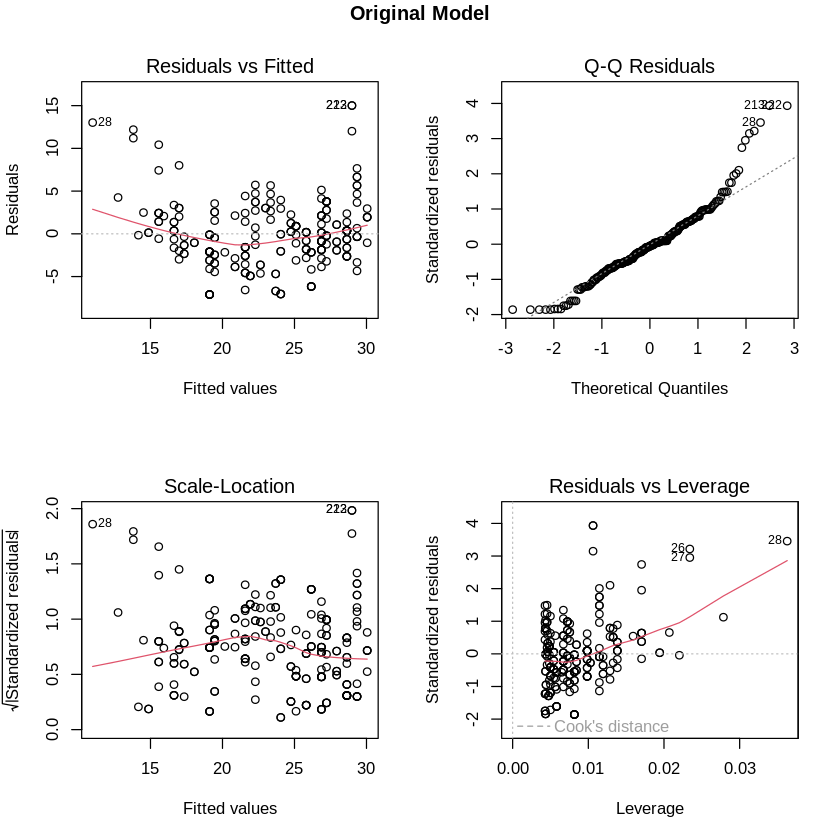

In [50]:
# Fit the transformed model (Log-Linear)
log_mpg_model <- lm(log(hwy) ~ displ, data = mpg)

# View the summary to compare R-squared and coefficients
summary(log_mpg_model)

# Generate diagnostic plots for the new model
par(mfrow = c(2, 2))
plot(log_mpg_model)
title(main = "Log Transformed Model", outer=TRUE, line = -1)

par(mfrow = c(2, 2)) # Arrange plots in a 2x2 grid
plot(mpg_model)
title(main = "Original Model", outer=TRUE, line = -1)



As we apply log transformation, we can can see changes on the 4 graphs. We can see the on Residuals vs Fitted graph that the horizonal line was flatter than the previous one. For the Normality of Residuals, it improved the linearity and variance but was not able to resolve the outliers in the data distribution. On the Homoscedasticity, the red line is much more horizontal. While there is still slight fluctuation, the spread of the residuals is more uniform accross the range of the fitted values compared to the original.   

**Part 5: Reflection (3 points)**
In 3–5 sentences, reflect on your experience using the mpg dataset:
- What you learned about the relationship between engine displacement and fuel efficiency
- Why checking model assumptions is important when working with real-world data

There is a clear negative correlation between the engine displacement and fuel effciency. The  larger engines generally consume more fuel.

When working with real-world data rarely fits a perfect line. Checking assumptions prevents us from making overconfident or biased predictions based on a flawed model.